<a href="https://colab.research.google.com/github/vloneonme/trew/blob/main/tsp_kr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

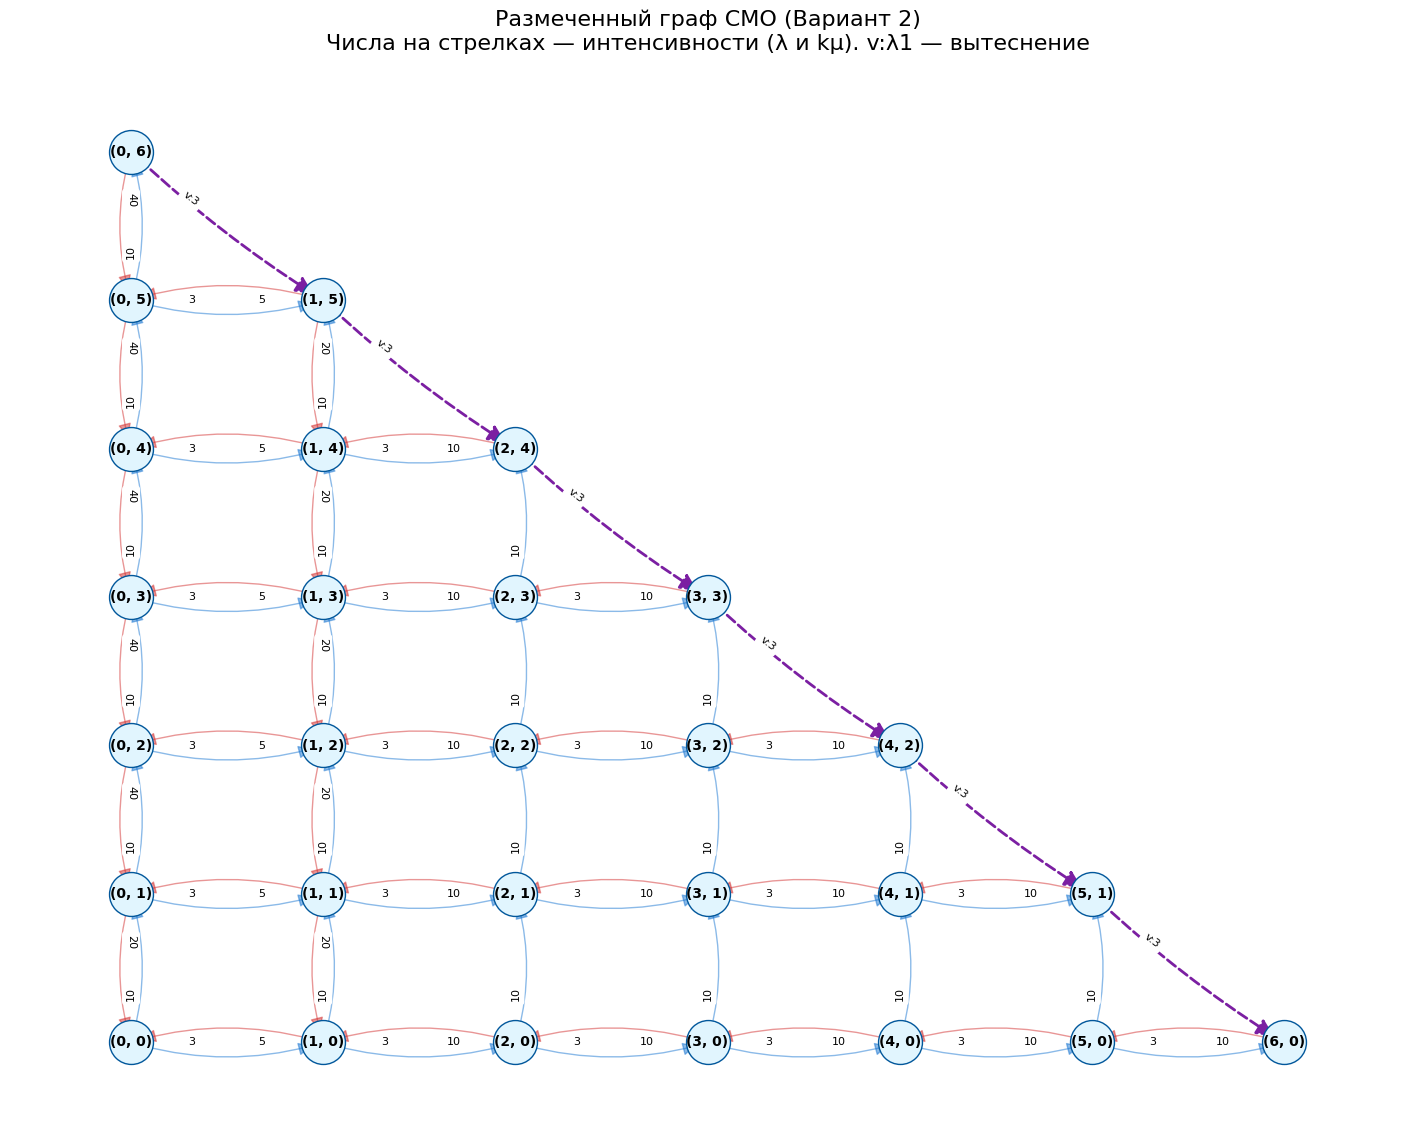

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# Параметры варианта 2
n, m = 2, 4
l1, l2 = 3, 10
m1, m2 = 5, 20
N_max = n + m

def draw_labeled_tmo_graph():
    G = nx.DiGraph()
    states = [(i, j) for i in range(N_max + 1) for j in range(N_max + 1) if i + j <= N_max]
    G.add_nodes_from(states)

    edge_labels = {}
    lambda_edges = []
    mu_edges = []
    eviction_edges = []

    for (i, j) in states:
        # Потоки λ1
        if i + j < N_max:
            edge = ((i, j), (i + 1, j))
            lambda_edges.append(edge)
            edge_labels[edge] = f'{l1}'
        elif i + j == N_max and j > 0:
            # Вытеснение
            edge = ((i, j), (i + 1, j - 1))
            eviction_edges.append(edge)
            edge_labels[edge] = f'v:{l1}'

        # Потоки λ2
        if i + j < N_max:
            edge = ((i, j), (i, j + 1))
            lambda_edges.append(edge)
            edge_labels[edge] = f'{l2}'

        # Потоки μ1 (зависит от числа каналов n=2)
        if i > 0:
            k1 = min(i, n)
            edge = ((i, j), (i - 1, j))
            mu_edges.append(edge)
            edge_labels[edge] = f'{k1*m1}'

        # Потоки μ2 (только если есть свободные от типа I каналы)
        k2 = min(j, max(0, n - i))
        if k2 > 0:
            edge = ((i, j), (i, j - 1))
            mu_edges.append(edge)
            edge_labels[edge] = f'{k2*m2}'

    plt.figure(figsize=(18, 14))
    # Увеличиваем расстояние между узлами для читаемости подписей
    pos = {state: (state[0] * 2.5, state[1] * 2.5) for state in states}

    # Узлы
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='#E1F5FE', edgecolors='#01579B')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Отрисовка ребер с изгибом
    # λ - синие
    nx.draw_networkx_edges(G, pos, edgelist=lambda_edges, edge_color='#1976D2',
                           connectionstyle='arc3,rad=0.15', arrowsize=20, alpha=0.5)
    # μ - красные
    nx.draw_networkx_edges(G, pos, edgelist=mu_edges, edge_color='#D32F2F',
                           connectionstyle='arc3,rad=0.15', arrowsize=20, alpha=0.5)
    # Вытеснение - фиолетовый
    nx.draw_networkx_edges(G, pos, edgelist=eviction_edges, edge_color='#7B1FA2',
                           width=2, style='dashed', connectionstyle='arc3,rad=0.05', arrowsize=25)

    # Подписи интенсивностей
    # Важно: для изогнутых линий label_pos помогает сместить текст, чтобы он не перекрывал линии
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

    plt.title(f"Размеченный граф СМО (Вариант 2)\nЧисла на стрелках — интенсивности (λ и kμ). v:λ1 — вытеснение", fontsize=16)
    plt.axis('off')
    plt.show()

draw_labeled_tmo_graph()

In [37]:
import numpy as np
import pandas as pd

def reshenie_smo():
    n = 2
    m = 4
    N = n + m
    l1, l2 = 3.0, 10.0
    m1, m2 = 5.0, 20.0
    states = [(i, j) for i in range(N + 1) for j in range(N + 1) if i + j <= N]
    state_to_idx = {state: idx for idx, state in enumerate(states)}
    num_states = len(states)

    Q = np.zeros((num_states, num_states))  # matric intensivnostey Q

    for idx, (i, j) in enumerate(states):
        k1 = min(i, n)
        if i > 0:
            Q[idx, state_to_idx[(i - 1, j)]] += k1 * m1
        k2 = min(j, max(0, n - i))
        if j > 0:
            Q[idx, state_to_idx[(i, j - 1)]] += k2 * m2
        if i + j < N:
            Q[idx, state_to_idx[(i + 1, j)]] += l1
        elif i + j == N and j > 0:
            Q[idx, state_to_idx[(i + 1, j - 1)]] += l1
        if i + j < N:
            Q[idx, state_to_idx[(i, j + 1)]] += l2

    for i in range(num_states):
        Q[i, i] = -np.sum(Q[i, :])

    # reshaem systemu P * Q = 0  sum(P) = 1
    A = Q.T
    A[-1, :] = 1
    B = np.zeros(num_states)
    B[-1] = 1
    probabilities = np.linalg.solve(A, B)
    results = []
    for idx, state in enumerate(states):
        results.append({"sostoyaniye (i,j)": str(state), "veroyatnost": round(probabilities[idx], 6)})
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    print(f"proverka sum veroyatnostey: {np.sum(probabilities):.4f}")

    return states, probabilities

if __name__ == "__main__":
    states, probabilities = reshenie_smo()

sostoyaniye (i,j)  veroyatnost
           (0, 0)     0.307634
           (0, 1)     0.161477
           (0, 2)     0.046097
           (0, 3)     0.015339
           (0, 4)     0.005717
           (0, 5)     0.001929
           (0, 6)     0.000449
           (1, 0)     0.153941
           (1, 1)     0.081700
           (1, 2)     0.042966
           (1, 3)     0.024664
           (1, 4)     0.014486
           (1, 5)     0.005429
           (2, 0)     0.021402
           (2, 1)     0.022145
           (2, 2)     0.018414
           (2, 3)     0.017182
           (2, 4)     0.017812
           (3, 0)     0.003043
           (3, 1)     0.005022
           (3, 2)     0.007318
           (3, 3)     0.013704
           (4, 0)     0.000578
           (4, 1)     0.001863
           (4, 2)     0.006285
           (5, 0)     0.000417
           (5, 1)     0.002201
           (6, 0)     0.000785
proverka sum veroyatnostey: 1.0000


In [11]:
# Среднее число заявок I и II типа в системе
z1_avg = sum(i * prob for (i, j), prob in zip(states, probabilities))
z2_avg = sum(j * prob for (i, j), prob in zip(states, probabilities))

print(f"Среднее число заявок I типа в системе (z1): {z1_avg:.4f}")
print(f"Среднее число заявок II типа в системе (z2): {z2_avg:.4f}")
print(f"общее среднее системе (z): {z1_avg+z2_avg:.4f}")

Среднее число заявок I типа в системе (z1): 0.6571
Среднее число заявок II типа в системе (z2): 0.9208
общее среднее системе (z): 1.5778


In [39]:
# k1_stat — число каналов, занятых типом I в состоянии (i,j)
# k2_stat — число каналов, занятых типом II в состоянии (i,j)
k1_avg = sum(min(i, n) * prob for (i, j), prob in zip(states, probabilities))
k2_avg = sum(min(j, max(0, n - i)) * prob for (i, j), prob in zip(states, probabilities))

print(f"Среднее число каналов, занятых типом I (k1) = {k1_avg:.4f}")
print(f"Среднее число каналов, занятых типом II (k2) = {k2_avg:.4f}")
print(f"k_общ = {k1_avg+k2_avg}")

Среднее число каналов, занятых типом I (k1) = 0.5995
Среднее число каналов, занятых типом II (k2) = 0.4698
k_общ = 1.0693143830995668


In [40]:
# Очередь — это разница между всеми заявками в системе и теми, что на каналах
r1_avg = z1_avg - k1_avg
r2_avg = z2_avg - k2_avg

print(f"Средняя длина очереди I типа (r1): {r1_avg:.4f}")
print(f"Средняя длина очереди II типа (r2): {r2_avg:.4f}")
print(f"r_общ = {r1_avg+r2_avg}")

Средняя длина очереди I типа (r1): 0.0575
Средняя длина очереди II типа (r2): 0.4510
r_общ = 0.5085285783312707


In [27]:
# Абсолютная пропускная способность (заявок в ед. времени)
A1 = k1_avg * m1
A2 = k2_avg * m2

# Относительная пропускная способность
Q1 = A1 / l1
Q2 = A2 / l2

# Исправленный расчет вероятностей отказа
p_otk1 = 1 - Q1
p_otk2 = 1 - Q2

# Общая вероятность отказа для всей системы (средневзвешенная)
p_otk_total = (l1 * p_otk1 + l2 * p_otk2) / (l1 + l2)

print(f"Вероятность отказа I типа: {p_otk1:.6f}")
print(f"Вероятность отказа II типа: {p_otk2:.4f}")
print(f"Общая вероятность отказа системы: {p_otk_total:.4f}")

print(f"Абсолютная пропускная способность (A1, A2): {A1:.4f}, {A2:.4f}")
print(f"Относительная пропускная способность (Q1, Q2): {Q1:.4f}, {Q2:.4f}")


Вероятность отказа I типа: 0.000785
Вероятность отказа II типа: 0.0604
Общая вероятность отказа системы: 0.0467
Абсолютная пропускная способность (A1, A2): 2.9976, 9.3957
Относительная пропускная способность (Q1, Q2): 0.9992, 0.9396


In [28]:
# Отказ для приоритетного потока - только состояние (6,0)
p_otk1 = probabilities[-1]

print(f"Вероятность отказа I типа: {p_otk1:.6f}")
print(f"Вероятность отказа II типа: {p_otk2:.6f}")

Вероятность отказа I типа: 0.000785
Вероятность отказа II типа: 0.060429


In [29]:
# Среднее время пребывания в системе
t_syst1 = z1_avg / A1
t_syst2 = z2_avg / A2

print(f"Время в системе I типа: {t_syst1:.4f}")
print(f"Время в системе II типа: {t_syst2:.4f}")

Время в системе I типа: 0.2192
Время в системе II типа: 0.0980


In [31]:
# Среднее время ожидания в очереди
t_wait1 = r1_avg / A1
t_wait2 = r2_avg / A2

print(f"Время в очереди I типа: {t_wait1:.4f}")
print(f"Время в очереди II типа: {t_wait2:.4f}")

Время в очереди I типа: 0.0192
Время в очереди II типа: 0.0480


In [30]:
# Общие временные характеристики
t_syst_total = (z1_avg + z2_avg) / (A1 + A2)
t_wait_total = (r1_avg + r2_avg) / (A1 + A2)

print(f"Общее среднее время в системе: {t_syst_total:.4f}")
print(f"Общее среднее время в очереди: {t_wait_total:.4f}")

Общее среднее время в системе: 0.1273
Общее среднее время в очереди: 0.0410
